In [34]:
import os
import torch

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Trening na urządzeniu: {device}")
if torch.cuda.is_available():
    print(f"Karta: {torch.cuda.get_device_name(0)}")

Trening na urządzeniu: cuda
Karta: NVIDIA GeForce RTX 3050 Laptop GPU


### Bez Augmentacji

In [36]:
# import tonic
# import tonic.transforms as transforms
# import tonic.collation
# from torch.utils.data import DataLoader, random_split

# sensor_size = tonic.datasets.NCALTECH101.sensor_size

# transform = transforms.Compose([
#     transforms.Downsample(spatial_factor=0.5),
#     transforms.CenterCrop(sensor_size=(120, 90), size=(80, 80)),
#     transforms.ToFrame(sensor_size=(80, 80, 2), time_window=10000) 
# ])

# dataset = tonic.datasets.NCALTECH101(save_to='./data', transform=transform)

# classes = sorted(set(dataset.targets))
# class_to_idx = {cls: i for i, cls in enumerate(classes)}
# dataset.targets = [class_to_idx[target] for target in dataset.targets]

# train_size = int(0.8 * len(dataset))
# val_size = len(dataset) - train_size
# train_set, val_set = random_split(dataset, [train_size, val_size])

# BATCH_SIZE = 8
# NUM_WORKERS = 0

# pad_tensors = tonic.collation.PadTensors(batch_first=False)

# train_loader = DataLoader(
#     train_set, 
#     batch_size=BATCH_SIZE, 
#     shuffle=True, 
#     drop_last=True,
#     num_workers=NUM_WORKERS,
#     collate_fn=pad_tensors
# )

# val_loader = DataLoader(
#     val_set, 
#     batch_size=BATCH_SIZE, 
#     shuffle=False, 
#     drop_last=True,
#     num_workers=NUM_WORKERS,
#     collate_fn=pad_tensors
# )

# print(f"Dane gotowe. Treningowe: {len(train_set)}, Walidacyjne: {len(val_set)}")

### Z Augmentacją

In [37]:
import tonic
import tonic.transforms as transforms
import tonic.collation
from torch.utils.data import DataLoader, random_split, Dataset
import numpy as np


class SafeDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        
    def __getitem__(self, idx):
        data, target = self.dataset[idx]
        while isinstance(data, np.ndarray) and data.dtype.names is not None:
            idx = np.random.randint(0, len(self.dataset))
            data, target = self.dataset[idx]
        return data, target

    def __len__(self):
        return len(self.dataset)

    
sensor_size = tonic.datasets.NCALTECH101.sensor_size

dataset = tonic.datasets.NCALTECH101(save_to='./data')

classes = sorted(set(dataset.targets))
class_to_idx = {cls: i for i, cls in enumerate(classes)}
dataset.targets = [class_to_idx[target] for target in dataset.targets]

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_subset, val_subset = random_split(dataset, [train_size, val_size])

train_transform = transforms.Compose([
    transforms.Downsample(spatial_factor=0.5),
    transforms.RandomCrop(sensor_size=(120, 90), target_size=(80, 80)),
    transforms.RandomFlipLR(sensor_size=(80, 80), p=0.5),
    transforms.ToFrame(sensor_size=(80, 80, 2), time_window=10000) 
])

val_transform = transforms.Compose([
    transforms.Downsample(spatial_factor=0.5),
    transforms.CenterCrop(sensor_size=(120, 90, 2), size=(80, 80, 2)),
    transforms.ToFrame(sensor_size=(80, 80, 2), time_window=10000) 
])

train_set = tonic.MemoryCachedDataset(train_subset, transform=train_transform)
val_set = tonic.MemoryCachedDataset(val_subset, transform=val_transform)


train_set_safe = SafeDataset(train_set)
val_set_safe = SafeDataset(val_set)

BATCH_SIZE = 8
NUM_WORKERS = 0

pad_tensors = tonic.collation.PadTensors(batch_first=False)

train_loader = DataLoader(
    train_set_safe, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=True,
    num_workers=NUM_WORKERS,
    collate_fn=pad_tensors
)

val_loader = DataLoader(
    val_set_safe,   
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=True,
    num_workers=NUM_WORKERS,
    collate_fn=pad_tensors
)

print(f"Dane gotowe. Treningowe: {len(train_set)}, Walidacyjne: {len(val_set)}")

Dane gotowe. Treningowe: 6967, Walidacyjne: 1742


In [38]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0):
      self.patience = patience
      self.min_delta = min_delta
      self.counter = 0
      self.best_loss =  float('inf')
      self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [39]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

class FranciszekSCNN(nn.Module):
    def __init__(self, beta=0.9, threshold=1.0, num_classes=101, population=10, dropout_p=0.3):
        super().__init__()
        
        spike_grad = surrogate.fast_sigmoid(slope=25)
        lif_params = {'learn_beta': True, 'learn_threshold': True, 'spike_grad': spike_grad}
        
        self.conv1 = nn.Conv2d(2, 24, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=beta, threshold=threshold, **lif_params)
        
        self.conv2 = nn.Conv2d(24, 48, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=beta, threshold=threshold, **lif_params)
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(48 * 6 * 6, 256) 
        self.lif3 = snn.Leaky(beta=beta, threshold=threshold, **lif_params)
        
        self.dropout = nn.Dropout(p=dropout_p)
        
        self.fc2 = nn.Linear(256, num_classes * population)
        self.lif4 = snn.Leaky(beta=beta, threshold=threshold, **lif_params)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        
        spk_rec = []
        
        for step in range(x.size(0)):
            cur1 = self.pool1(self.conv1(x[step]))
            spk1, mem1 = self.lif1(cur1, mem1)
            
            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)
            
            cur3 = self.fc1(self.flatten(self.adaptive_pool(spk2)))
            spk3, mem3 = self.lif3(cur3, mem3)
            
            spk3_dropped = self.dropout(spk3)
            
            cur4 = self.fc2(spk3_dropped)
            spk4, mem4 = self.lif4(cur4, mem4)
            
            spk_rec.append(spk4)
            
        return torch.stack(spk_rec, dim=0), mem4

### OPTUNA

In [40]:
# import optuna
# import snntorch.functional as SF
# import gc


# def objective(trial):
#     lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
#     weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
#     beta_init = trial.suggest_float("beta_init", 0.8, 0.99)
#     threshold_init = trial.suggest_float("threshold", 0.5, 1.5)
    
#     model = FranciszekSCNN(beta=beta_init, threshold=threshold_init).to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
#     loss_fn = SF.ce_count_loss(population_code=True, num_classes=101)
    
#     early_stopping = EarlyStopping(patience=2, min_delta=0.001)
#     epochs = 10
    
#     for epoch in range(epochs):
#         model.train()
#         train_loss = 0
        
#         for data, targets in train_loader:
#             data, targets = data.to(device, dtype=torch.float), targets.to(device, dtype=torch.long)
            
#             spk_out, _ = model(data)
#             loss = loss_fn(spk_out, targets)
            
#             optimizer.zero_grad(set_to_none=True)
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item()
            
#         model.eval()
#         val_loss = 0
#         with torch.no_grad():
#             for data, targets in val_loader:
#                 data, targets = data.to(device, dtype=torch.float), targets.to(device, dtype=torch.long)
#                 spk_out, _ = model(data)
#                 loss = loss_fn(spk_out, targets)
#                 val_loss += loss.item()
                
#         avg_val_loss = val_loss / len(val_loader)
        
#         trial.report(avg_val_loss, epoch)
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
            
#         early_stopping(avg_val_loss)
#         if early_stopping.early_stop:
#             break
            
#     del model, optimizer
#     gc.collect()
#     torch.cuda.empty_cache()
    
#     return early_stopping.best_loss

In [41]:
# print("Uruchamiam poszukiwanie optymalnych parametrów...")
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=3) 

# print("\nNajlepsze parametry do wykorzystania w aplikacji:")
# for key, value in study.best_trial.params.items():
#     print(f"  {key}: {value}")

In [42]:
# import optuna.visualization as vis

# fig_history = vis.plot_optimization_history(study)
# fig_history.show()

# fig_importances = vis.plot_param_importances(study)
# fig_importances.show()

Generowanie animacji...


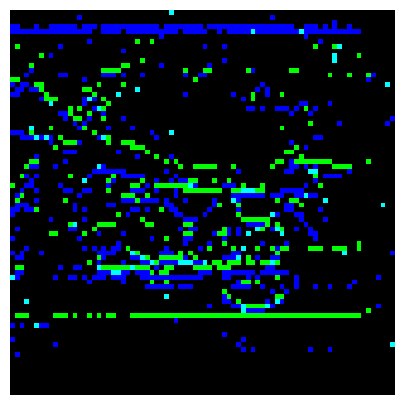

In [43]:
from IPython.display import HTML
import tonic.utils
import torch

data, targets = next(iter(train_loader))

sample_frames = data[:, 0, :, :, :] 

sample_frames = torch.clamp(sample_frames, min=0, max=1)

frames_np = sample_frames.numpy()
print("Generowanie animacji...")
animation = tonic.utils.plot_animation(frames_np)
HTML(animation.to_jshtml())

In [ ]:
from tqdm import tqdm
import snntorch.functional as SF

best_params = {
    'lr': 0.0002817302378982754, 
    'weight_decay': 1.4118544167963607e-05, 
    'beta_init': 0.8043928228496409, 
    'threshold': 1.0963622894441234
}
print(f"Inicjalizacja z parametrami: {best_params}")

model = FranciszekSCNN(beta=best_params['beta_init'], threshold=best_params['threshold']).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=best_params['lr'], 
    weight_decay=best_params['weight_decay']
)
loss_fn = SF.ce_count_loss(population_code=True, num_classes=101)

epochs = 30

print("\nRozpoczynam trening z metryką Accuracy...")
for epoch in range(epochs):
    model.train()
    train_loss, train_acc, total = 0, 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{epochs}")
    
    for data, targets in pbar:
        data, targets = data.to(device, dtype=torch.float), targets.to(device, dtype=torch.long)
        
        spk_out, _ = model(data)
        loss = loss_fn(spk_out, targets)
        
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
         
        acc = SF.accuracy_rate(spk_out, targets, population_code=True, num_classes=101)
        train_acc += acc * data.size(0) 
        total += data.size(0)
        
        pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{acc:.2%}"})
        
    avg_loss = train_loss / len(train_loader)
    avg_acc = train_acc / total
    print(f"Podsumowanie epoki {epoch+1}: Średni Loss: {avg_loss:.4f} | Średnie Accuracy: {avg_acc:.2%}\n")

torch.save(model.state_dict(), 'franciszek_scnn_final.pth')
print("\nGotowe! Wagi modelu zapisane w pliku 'franciszek_scnn_final.pth'.")

Inicjalizacja z parametrami: {'lr': 0.0002817302378982754, 'weight_decay': 1.4118544167963607e-05, 'beta_init': 0.8043928228496409, 'threshold': 1.0963622894441234}

Rozpoczynam trening z metryką Accuracy...


Epoka 1/30:   0%|          | 0/870 [00:00<?, ?it/s]

Epoka 1/30: 100%|██████████| 870/870 [04:07<00:00,  3.52it/s, Loss=4.1413, Acc=25.00%]


Podsumowanie epoki 1: Średni Loss: 3.9313 | Średnie Accuracy: 21.48%



Epoka 2/30: 100%|██████████| 870/870 [03:38<00:00,  3.98it/s, Loss=4.0413, Acc=12.50%]


...

Epoka 13/30: 100%|██████████| 870/870 [04:54<00:00,  2.95it/s, Loss=1.5266, Acc=62.50%] 


Podsumowanie epoki 13: Średni Loss: 2.3918 | Średnie Accuracy: 44.20%



Epoka 14/30: 100%|██████████| 870/870 [05:28<00:00,  2.65it/s, Loss=3.1820, Acc=50.00%] 


Podsumowanie epoki 14: Średni Loss: 2.3253 | Średnie Accuracy: 45.74%



Epoka 15/30:   9%|▉         | 78/870 [00:17<02:51,  4.62it/s, Loss=2.3919, Acc=50.00%]

In [ ]:
import torch
import snntorch.functional as SF
from tqdm import tqdm

model = FranciszekSCNN(beta=0.8043928228496409, threshold=1.0963622894441234).to(device)

model.load_state_dict(torch.load('franciszek_scnn_best.pth'))

model.eval() 

test_acc = 0
total = 0

print("Rozpoczynam testowanie modelu...")

with torch.no_grad(): 
    for data, targets in tqdm(val_loader, desc="Testowanie"):
        data = data.to(device, dtype=torch.float)
        targets = targets.to(device, dtype=torch.long)
        
        spk_out, _ = model(data)
        
        acc = SF.accuracy_rate(spk_out, targets, population_code=True, num_classes=101)
        test_acc += acc * data.size(0)
        total += data.size(0)

final_test_acc = test_acc / total
print(f"\nOstateczny wynik Test Accuracy: {final_test_acc:.2%}")

c:\Users\Franciszek\Documents\ml-neuromorficzne-widzenie\.venv\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
C:\Users\Franciszek\AppData\Local\Temp\ipykernel_23152\363924850.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by

Rozpoczynam testowanie modelu na nieznanych danych...


Testowanie: 100%|██████████| 217/217 [00:48<00:00,  4.49it/s]


Ostateczny wynik Test Accuracy: 57.08%
